In [1]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import random
from sklearn.metrics import r2_score
import math
from sklearn.cluster import AgglomerativeClustering as ac
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
from sklearn.cluster import KMeans
import sys
from scipy.spatial import cKDTree
from scipy.ndimage import label, binary_dilation
import numpy.polynomial.polynomial as poly
from PIL import Image
import copy
import warnings
np.set_printoptions(threshold=sys.maxsize)

In [2]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [3]:
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('C:\\Users\\2020\\Documents\\3 Academics\\Cambridge\\Publications\\Computer Vision\\Figures and Original Soln\\pics')

In [4]:
img1 = pics[-2].astype('uint8')
img1[2][2] = 50; img1[2][6] = 0; img1[3][2] = 50; img1[3][3] = 50; img1[3][4] = 50; img1[3][5] = 50; img1[4][2] = 50; img1[4][4] = 0
img1[4][5] = 50; img1[4][6] = 50; img1[5][2] = 50; img1[5][3] = 50; img1[5][4] = 50; img1[5][5] = 50; img1[5][6] = 50

img2 = pics[-2].astype('uint8')
img2[2][2] = 50; img2[2][6] = 0; img2[3][2] = 50; img2[3][3] = 50; img2[3][4] = 50; img2[3][5] = 50; img2[4][2] = 50; img2[4][4] = 0
img2[4][5] = 50; img2[4][6] = 50; img2[5][2] = 50; img2[5][3] = 50; img2[5][4] = 50; img2[5][5] = 50; img2[5][6] = 50
img2[0][0] = [255,255,60]; img2[0][1] = [255,255,60]; img2[0][2] = [255,255,60];   img2[0][3] = [255,255,60]; img2[0][4] = [255,255,60]
img2[0][5] = [255,255,60]; img2[0][6] = [255,255,60]; img2[0][7] = [255,255,60]; img2[7][0] = [255,255,60]; img2[7][1] = [255,255,60]
img2[7][2] = [255,255,60]; img2[7][3] = [255,255,60]; img2[7][4] = [255,255,60]; img2[7][5] = [255,255,60]; img2[7][6] = [255,255,60]
img2[7][7] = [255,255,60]; img2[1][0] = [255,255,60]; img2[2][0] = [255,255,60]; img2[3][0] = [255,255,60]; img2[4][0] = [255,255,60]
img2[5][0] = [255,255,60]; img2[6][0] = [255,255,60]; img2[1][7] = [255,255,60]; img2[2][7] = [255,255,60]; img2[3][7] = [255,255,60]
img2[4][7] = [255,255,60]; img2[5][7] = [255,255,60]; img2[6][7] = [255,255,60]; img2[1][1] = [255,255,60]; img2[2][1] = [255,255,60]
img2[3][1] = [255,255,60]; img2[4][1] = [255,255,60]; img2[5][1] = [255,255,60]; img2[6][1] = [255,255,60]; img2[6][2] = [255,255,60]
img2[6][3] = [255,255,60]; img2[6][4] = [255,255,60]; img2[6][5] = [255,255,60]; img2[6][6] = [255,255,60]; img2[6][7] = [255,255,60]
img2[3][6] = [60,255,255]
#f, axarr = plt.subplots(1,2)
#axarr[0].imshow(img1[...,::-1])
#axarr[1].imshow(img2[...,::-1])

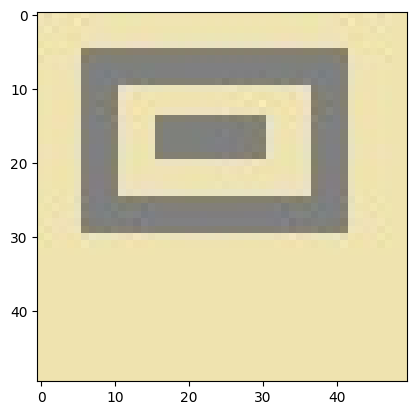

In [5]:
chosenImage = pics[4]
# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [6]:
def checkFit(cMean, pixel):
    # Compute current cluster mean
    h_mean = np.mean(cMean[0])
    s_mean = np.mean(cMean[1])
    v_mean = np.mean(cMean[2])
    
    # Circular hue difference (normalized to [0,1])
    dh = min(abs(pixel[0] - h_mean), 180 - abs(pixel[0] - h_mean)) / 180.0
    
    # Saturation and value differences (normalized)
    ds = abs(pixel[1] - s_mean) / 255.0
    dv = abs(pixel[2] - v_mean) / 255.0
    
    # Weighted distance: emphasize hue, de-emphasize value
    return np.sqrt((2 * dh)**2 + ds**2 + (0.5 * dv)**2)

In [ ]:
# Convert input image to HSV 
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

# Remove old compressed file if it exists 
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID
clustMeans = []             # mean HSV per cluster
thresh = 0.10               # color similarity threshold
percentMerge = 0.05         # minimum cluster size as % of image

# 4-connected neighborhood definition
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]])

# Continue until all pixels have been assigned
while np.count_nonzero(visited) > 0:

    firstFind = 0            # flag to find seed pixel
    clust = []               # border pixels for this cluster

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            if visited[i][j] == 1 and firstFind == 0:
                # First unvisited pixel becomes the seed
                startX, startY = i, j

                # Cluster mean stored as lists
                cMean = [[], [], []]
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

                firstFind = 1

    # ---- STEP 2: build the similarity mask, replaces recursion ----
    # fitMask[i,j] = True if pixel is unvisited AND fits cluster mean
    fitMask = np.zeros((img.shape[0], img.shape[1]), dtype=bool)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if visited[i][j] == 1:
                if checkFit(cMean, img[i][j]) < thresh:
                    fitMask[i][j] = True

    # ---- STEP 3: connected component labeling (4-connected) ----
    # Each connected region of True pixels gets a unique label
    labels, numLabels = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:
                visited[i][j] = 0                # mark as assigned
                imgClusters[i][j] = clusterNum   # assign cluster

                # update cluster mean
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

    # ---- STEP 5: border detection ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:

                # Check 4 neighbors only (same as recursion logic)
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj

                    # Absolute image border - border pixel
                    if ni < 0 or nj < 0 or ni >= img.shape[0] or nj >= img.shape[1]:
                        clust.append((i, j))
                        break

                    # Neighbor not in same component - border pixel
                    if not region[ni][nj]:
                        clust.append((i, j))
                        break

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(list(set(clust)))

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1


In [ ]:
# Percent merge function
img_area = img.shape[0] * img.shape[1]
rowsToDelete = set()

for i in range(len(clusterEdges)):
    if i in rowsToDelete:
        continue
    if len(clusterEdges[i]) == 0:
        rowsToDelete.add(i)
        continue

    if (len(clusterEdges[i]) / img_area) < percentMerge:
        src_pts = np.array(clusterEdges[i], dtype=float)
        src_center = np.mean(src_pts, axis=0)

        best_j = -1
        best_dist = float('inf')

        for j in range(len(clusterEdges)):
            if j == i or j in rowsToDelete or len(clusterEdges[j]) == 0:
                continue
            dst_pts = np.array(clusterEdges[j], dtype=float)
            dst_center = np.mean(dst_pts, axis=0)
            d = np.linalg.norm(src_center - dst_center)
            if d < best_dist:
                best_dist = d
                best_j = j

        if best_j == -1:
            continue

        for r, c in clusterEdges[i]:
            rr, cc = int(r), int(c)
            if 0 <= rr < img.shape[0] and 0 <= cc < img.shape[1]:
                imgClusters[rr, cc] = best_j + 1

        merged = set(clusterEdges[best_j])
        merged.update(clusterEdges[i])
        clusterEdges[best_j] = list(merged)

        rowsToDelete.add(i)

for row in sorted(rowsToDelete, reverse=True):
    del clusterEdges[row]
    del clustMeans[row]


In [ ]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [10]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [11]:
# Build masks
cluster_masks = {}
for k in range(1, clusterNum):
    cluster_masks[k] = (imgClusters == k)

# Determine hole relationships
holes_of = {k: [] for k in cluster_masks}

for outer in cluster_masks:
    outer_mask = cluster_masks[outer]
    dilated_outer = binary_dilation(outer_mask)

    for inner in cluster_masks:
        if inner == outer:
            continue

        inner_mask = cluster_masks[inner]

        # inner fully enclosed by outer
        if np.all(dilated_outer[inner_mask]):
            holes_of[outer].append(inner)
all_holes = set(h for hs in holes_of.values() for h in hs)
top_level_clusters = [k for k in holes_of if k not in all_holes]

In [ ]:
# Fit to polynomial
def polyFit(x,y):
    y = np.array(y)
    x = np.array(x)

    # Sort by x-coordinate for better contour fitting
    #print("Pre sort:", x, y)
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    #print("In fitting:", x, y)
    if len(x) <= 1:
        return np.array([y[0]])  # trivial fit for single point
    for i in range(0,6):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=np.exceptions.RankWarning)
            pol = np.poly1d(np.polyfit(x, y, i))
        #print("Degree", i)
        test = pol(x).astype(int)
        #print("Res:", r2_score(y, pol(x)))
        if r2_score(y, pol(x)) > 0.9 or i == 5:
            #print("here", r2_score(y, pol(x)), pol.c)
            #print(pol(x), y)
            return pol.c

In [13]:
def write_loop(f, loop_points):
    # Serialize one contour loop as raw pixel coordinates
    if not loop_points:
        return

    cleaned = []
    seen = set()
    for r, c in loop_points:
        rr, cc = int(r), int(c)
        # Preserve order but drop exact duplicates
        if (rr, cc) == (cleaned[-1] if cleaned else (None, None)):
            continue
        cleaned.append((rr, cc))

    if len(cleaned) < 3:
        return

    payload = ';'.join(f"{r},{c}" for r, c in cleaned)
    f.write(f"L;{payload}\n")



In [14]:
with open("imComp.txt", "w") as f:
    edge_by_id = {idx + 1: edge for idx, edge in enumerate(clusterEdges)}
    mean_by_id = {idx + 1: mean for idx, mean in enumerate(clustMeans)}

    for outer in top_level_clusters:
        try:
            outer_id = int(outer)
        except Exception:
            continue

        outer_edge = edge_by_id.get(outer_id)
        outer_mean = mean_by_id.get(outer_id)
        if outer_edge is None or outer_mean is None or len(outer_edge) < 3:
            continue

        f.write(f"C;{outer_mean[0]},{outer_mean[1]},{outer_mean[2]}\n")

        # Outer contour
        write_loop(f, outer_edge)
        f.write(".\n")

        # Hole contours
        for h in holes_of.get(outer, []):
            try:
                hole_id = int(h)
            except Exception:
                continue
            hole_edge = edge_by_id.get(hole_id)
            if hole_edge is None or len(hole_edge) < 3:
                continue
            f.write("H\n")
            write_loop(f, hole_edge)
            f.write(".\n")

        anchor = outer_edge[0]
        f.write(f"E;{anchor[0]},{anchor[1]}\n\n")


In [ ]:
# Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 6096
JPEG compress: 1123
PNG compress: 2413
Tiff compress: 7640


In [16]:
def draw_region(color, outer, holes, image):
    # Outer must be a valid polygon
    if outer is None or len(outer) < 3:
        return

    outer_poly = np.array([[int(p[1]), int(p[0])] for p in outer], dtype=np.int32).reshape((-1, 1, 2))
    if outer_poly.shape[0] < 3:
        return

    cv2.fillPoly(image, [outer_poly], tuple(int(v) for v in color))

    # Carve holes by filling with background (black in HSV image)
    for hole in holes:
        if hole is None or len(hole) < 3:
            continue
        hole_poly = np.array([[int(p[1]), int(p[0])] for p in hole], dtype=np.int32).reshape((-1, 1, 2))
        if hole_poly.shape[0] < 3:
            continue
        cv2.fillPoly(image, [hole_poly], (0, 0, 0))



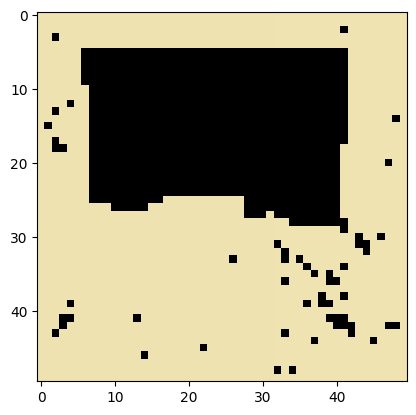

In [ ]:
H, W = img.shape[:2]
imRecover = np.zeros((H, W, 3), dtype=np.uint8)


def parse_loop_line(line):
    # L;r,c;r,c;...
    parts = line.split(';')[1:]
    pts = []
    for part in parts:
        if not part:
            continue
        rc = part.split(',')
        if len(rc) != 2:
            continue
        try:
            r = int(float(rc[0]))
            c = int(float(rc[1]))
        except ValueError:
            continue
        pts.append((r, c))
    return pts


current_color = None
outer_loop = []
hole_loops = []
current_loop = []
reading_hole = False

with open("imComp.txt", "r") as f:
    for raw in f:
        line = raw.strip()
        if not line:
            continue

        if line.startswith("C;"):
            _, col = line.split(";", 1)
            current_color = tuple(int(v) for v in col.split(","))
            outer_loop = []
            hole_loops = []
            current_loop = []
            reading_hole = False

        elif line == "H":
            if reading_hole and len(current_loop) >= 3:
                hole_loops.append(current_loop)
            current_loop = []
            reading_hole = True

        elif line.startswith("L;"):
            pts = parse_loop_line(line)
            current_loop.extend(pts)

        elif line == ".":
            if reading_hole:
                if len(current_loop) >= 3:
                    hole_loops.append(current_loop)
            else:
                if len(current_loop) >= 3:
                    outer_loop = current_loop
            current_loop = []

        elif line.startswith("E;"):
            if current_color is not None:
                draw_region(current_color, outer_loop, hole_loops, imRecover)

plt.imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
plt.show()



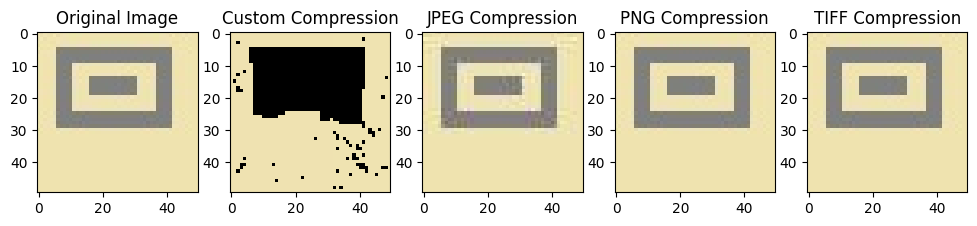

In [ ]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(chosenImage[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])  # BGR to RGB for matplotlib
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])  # BGR to RGB for matplotlib
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])  # BGR to RGB for matplotlib
axarr[4].title.set_text('TIFF Compression')